# 🏠 Modèle Unifié de Prédiction Immobilière - 20 Villes

Ce notebook crée un modèle unique capable de prédire les prix immobiliers sur 20 villes françaises.

In [51]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
import json
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Bibliothèques supplémentaires pour la visualisation interactive
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Widgets interactifs
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# XGBoost pour les modèles alternatifs
import xgboost as xgb


In [52]:
# Détecter les villes depuis le fichier CSV
def detecter_villes_csv():
    """Détecte dynamiquement les villes disponibles dans le fichier CSV"""
    
    csv_path = Path().resolve() / "generated_properties.csv"
    
    try:
        if csv_path.exists():
            # Charger le CSV
            df = pd.read_csv(csv_path)
            
            # Chercher la colonne des villes (noms possibles)
            colonnes_ville = ['city', 'ville', 'City', 'location', 'Location', 'address']
            colonne_ville_trouvee = None
            
            for col in colonnes_ville:
                if col in df.columns:
                    colonne_ville_trouvee = col
                    break
            
            if colonne_ville_trouvee:
                # Obtenir les villes uniques (exclure les valeurs manquantes)
                villes_uniques = df[colonne_ville_trouvee].dropna().unique()
                
                # Nettoyer les noms de villes
                villes_propres = []
                for ville in villes_uniques:
                    ville_str = str(ville).strip().title()
                    if len(ville_str) > 0 and ville_str.lower() != 'nan':
                        villes_propres.append(ville_str)
                
                # Trier par ordre alphabétique
                villes_propres.sort()
                
                # Codes postaux (si disponibles)
                codes_postaux = {}
                
                # Chercher la colonne des codes postaux
                colonnes_cp = ['postal_code', 'code_postal', 'PostalCode', 'zip', 'Zip']
                colonne_cp_trouvee = None
                
                for col in colonnes_cp:
                    if col in df.columns:
                        colonne_cp_trouvee = col
                        break
                
                if colonne_cp_trouvee:
                    # Créer un mapping ville -> code postal (prendre le premier code postal trouvé)
                    for ville in villes_propres:
                        cp = df[df[colonne_ville_trouvee].astype(str).str.strip().str.title() == ville][colonne_cp_trouvee].iloc[0] if len(df[df[colonne_ville_trouvee].astype(str).str.strip().str.title() == ville]) > 0 else None
                        if pd.notna(cp):
                            codes_postaux[ville] = str(int(cp)).zfill(5) if '.' in str(cp) else str(cp).zfill(5)
                
                return villes_propres, codes_postaux
            else:
                print("⚠️ Aucune colonne de ville trouvée dans le CSV")
                print(f"Colonnes disponibles: {df.columns.tolist()}")
                return [], {}
        else:
            print(f"❌ Fichier CSV non trouvé: {csv_path}")
            return [], {}
            
    except Exception as e:
        print(f"❌ Erreur lors de la détection des villes: {e}")
        return [], {}

# Détecter les villes depuis le CSV
villes_disponibles, codes_postaux = detecter_villes_csv()

print(f"🏙️ {len(villes_disponibles)} villes détectées dans le CSV")
if villes_disponibles:
    print(f"📋 Villes disponibles: {len(villes_disponibles)}")
    print("🔍 Exemples de villes:")
    for i, ville in enumerate(villes_disponibles[:10]):
        cp = codes_postaux.get(ville, "N/A")
        print(f"   - {ville} ({cp})")
    
    if len(villes_disponibles) > 10:
        print(f"   ... et {len(villes_disponibles) - 10} autres")
        
    # Statistiques sur les villes
    print(f"\n📊 Statistiques des villes:")
    print(f"   - Total: {len(villes_disponibles)} villes")
    print(f"   - Avec code postal: {len(codes_postaux)} villes")
    
    # Compter les biens par ville si on veut
    try:
        csv_path = Path().resolve() / "generated_properties.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            
            # Trouver la colonne ville
            colonnes_ville = ['city', 'ville', 'City', 'location', 'Location']
            colonne_ville_trouvee = None
            for col in colonnes_ville:
                if col in df.columns:
                    colonne_ville_trouvee = col
                    break
            
            if colonne_ville_trouvee:
                biens_par_ville = df[colonne_ville_trouvee].value_counts().head(10)
                print(f"\n🏠 Nombre de biens par ville (top 10):")
                for ville, count in biens_par_ville.items():
                    print(f"   - {ville}: {count} biens")
                    
    except Exception as e:
        print(f"⚠️ Erreur lors du comptage des biens: {e}")
else:
    print("⚠️ Aucune ville détectée")
    print("💡 Le notebook utilisera des données d'exemple si nécessaire")

🏙️ 20 villes détectées dans le CSV
📋 Villes disponibles: 20
🔍 Exemples de villes:
   - Aix-En-Provence (13100)
   - Angers (49000)
   - Bordeaux (33000)
   - Brest (29200)
   - Clermont-Ferrand (63000)
   - Dijon (21000)
   - Grenoble (38000)
   - Le Mans (72000)
   - Lille (59000)
   - Lyon (69001)
   ... et 10 autres

📊 Statistiques des villes:
   - Total: 20 villes
   - Avec code postal: 20 villes

🏠 Nombre de biens par ville (top 10):
   - Toulouse: 118 biens
   - Saint-Étienne: 115 biens
   - Lyon: 114 biens
   - Nantes: 107 biens
   - Rennes: 106 biens
   - Dijon: 105 biens
   - Lille: 105 biens
   - Montpellier: 104 biens
   - Nîmes: 103 biens
   - Bordeaux: 100 biens


In [53]:
# Chargement des données depuis le fichier CSV
def charger_donnees_csv():
    """Charge les données immobilières depuis le fichier CSV"""
    
    csv_path = Path().resolve() / "generated_properties.csv"
    
    try:
        if csv_path.exists():
            print(f"📁 Fichier CSV trouvé: {csv_path}")
            
            # Charger le CSV
            df = pd.read_csv(csv_path)
            print(f"✅ {len(df)} enregistrements chargés depuis le CSV")
            print(f"📋 Colonnes disponibles: {df.columns.tolist()}")
            
            # Afficher les premières lignes du CSV brut
            print("\n🔍 Aperçu des données brutes:")
            display(df.head())
            
            # Nettoyage et préparation des données
            df_clean = pd.DataFrame()
            
            # Mapping des colonnes (adapter selon le format réel du CSV)
            colonnes_mapping = {
                # Colonnes possibles dans le CSV -> colonnes standardisées
                'city': 'ville',
                'ville': 'ville',
                'City': 'ville',
                'postal_code': 'code_postal',
                'code_postal': 'code_postal',
                'PostalCode': 'code_postal',
                'price': 'prix_euros',
                'prix': 'prix_euros',
                'Price': 'prix_euros',
                'surface': 'surface_m2',
                'surface_m2': 'surface_m2',
                'Surface': 'surface_m2',
                'property_type': 'type_bien',
                'type': 'type_bien',
                'Type': 'type_bien',
                'title': 'type_bien',
                'rooms': 'nombre_pieces',
                'rooms_count': 'nombre_pieces',
                'nb_rooms': 'nombre_pieces',
                'land_area': 'surface_terrain',
                'surface_terrain': 'surface_terrain',
                'garden_area': 'surface_terrain'
            }
            
            # Appliquer le mapping
            for csv_col, std_col in colonnes_mapping.items():
                if csv_col in df.columns:
                    df_clean[std_col] = df[csv_col]
                    print(f"   ✓ {csv_col} -> {std_col}")
            
            # Si pas de ville, essayer de la déduire du code postal
            if 'ville' not in df_clean.columns and 'code_postal' in df_clean.columns:
                # Mapping simple code postal -> ville
                cp_ville = {
                    '75': 'Paris', '69': 'Lyon', '13': 'Marseille', '33': 'Bordeaux',
                    '31': 'Toulouse', '06': 'Nice', '44': 'Nantes', '67': 'Strasbourg',
                    '59': 'Lille', '29': 'Brest', '34': 'Montpellier', '35': 'Rennes',
                    '38': 'Grenoble', '21': 'Dijon', '49': 'Angers', '42': 'Saint-Étienne',
                    '30': 'Nîmes', '13': 'Aix-en-Provence', '72': 'Le Mans'
                }
                
                def get_ville_from_cp(cp):
                    cp_str = str(cp)[:2]
                    return cp_ville.get(cp_str, 'Autre')
                
                df_clean['ville'] = df_clean['code_postal'].apply(get_ville_from_cp)
                print("   ✓ Ville déduite du code postal")
            
            # Calculer le prix au m² si manquant
            if 'prix_m2' not in df_clean.columns:
                if 'prix_euros' in df_clean.columns and 'surface_m2' in df_clean.columns:
                    df_clean['prix_m2'] = df_clean['prix_euros'] / df_clean['surface_m2']
                    print("   ✓ Prix/m² calculé")
            
            # Calculer le nombre de pièces si manquant
            if 'nombre_pieces' not in df_clean.columns:
                if 'surface_m2' in df_clean.columns:
                    def calculer_nb_pieces(surface):
                        if pd.isna(surface):
                            return 2
                        if surface < 40:
                            return 1
                        elif surface < 60:
                            return 2
                        elif surface < 90:
                            return 3
                        elif surface < 120:
                            return 4
                        else:
                            return 5
                    
                    df_clean['nombre_pieces'] = df_clean['surface_m2'].apply(calculer_nb_pieces)
                    print("   ✓ Nombre de pièces calculé")
            
            # Surface terrain pour les maisons
            if 'surface_terrain' not in df_clean.columns:
                if 'type_bien' in df_clean.columns and 'surface_m2' in df_clean.columns:
                    def calculer_surface_terrain(row):
                        if pd.notna(row['type_bien']) and 'maison' in str(row['type_bien']).lower():
                            return max(0, int(row['surface_m2'] * 2.5))
                        return 0
                    
                    df_clean['surface_terrain'] = df_clean.apply(calculer_surface_terrain, axis=1)
                    print("   ✓ Surface terrain calculée")
            
            # Nettoyage final
            if 'type_bien' in df_clean.columns:
                df_clean['type_bien'] = df_clean['type_bien'].fillna('Inconnu')
                df_clean['type_bien'] = df_clean['type_bien'].apply(lambda x: 
                    'Maison' if 'maison' in str(x).lower() 
                    else 'Appartement' if 'appart' in str(x).lower() or 'apartment' in str(x).lower()
                    else 'Autre'
                )
            
            # Filtrer les valeurs aberrantes
            if 'surface_m2' in df_clean.columns and 'prix_m2' in df_clean.columns:
                # Garder seulement les surfaces entre 15 et 300m²
                df_clean = df_clean[(df_clean['surface_m2'] >= 15) & (df_clean['surface_m2'] <= 300)]
                
                # Garder seulement les prix au m² raisonnables
                df_clean = df_clean[(df_clean['prix_m2'] >= 100) & (df_clean['prix_m2'] <= 50000)]
                print(f"   ✓ Filtre appliqué: {len(df_clean)} enregistrements conservés")
            
            # Ajouter des colonnes manquantes avec des valeurs par défaut
            colonnes_obligatoires = ['ville', 'code_postal', 'type_bien', 'surface_m2', 
                                   'nombre_pieces', 'surface_terrain', 'prix_euros', 'prix_m2']
            
            for col in colonnes_obligatoires:
                if col not in df_clean.columns:
                    if col == 'ville':
                        df_clean[col] = 'Paris'
                    elif col == 'code_postal':
                        df_clean[col] = '75001'
                    elif col == 'type_bien':
                        df_clean[col] = 'Appartement'
                    elif col in ['surface_m2', 'nombre_pieces']:
                        df_clean[col] = 50
                    elif col == 'surface_terrain':
                        df_clean[col] = 0
                    elif col == 'prix_euros':
                        df_clean[col] = 200000
                    elif col == 'prix_m2':
                        df_clean[col] = 4000
                    print(f"   ✓ Colonne {col} ajoutée avec valeur par défaut")
            
            return df_clean
            
        else:
            print(f"❌ Fichier CSV non trouvé: {csv_path}")
            print("💡 Création de données d'exemple...")
            return creer_donnees_exemple()
            
    except Exception as e:
        print(f"❌ Erreur lors de la lecture du CSV: {e}")
        print("💡 Création de données d'exemple...")
        return creer_donnees_exemple()

# Créer des données d'exemple si nécessaire
def creer_donnees_exemple():
    """Crée un jeu de données d'exemple pour démonstration"""
    print("🔄 Création d'un jeu de données d'exemple...")
    
    np.random.seed(42)
    n_samples = 1000
    
    # Villes et prix moyens
    villes_data = {
        'Paris': 10000, 'Lyon': 4500, 'Marseille': 3800, 'Bordeaux': 4200,
        'Toulouse': 3600, 'Nice': 5000, 'Nantes': 3700, 'Strasbourg': 3400,
        'Lille': 3200, 'Brest': 2800, 'Montpellier': 3800, 'Rennes': 3200
    }
    
    data = []
    for ville, prix_moyen in villes_data.items():
        n = n_samples // len(villes_data)
        
        # Générer des données pour chaque ville
        surfaces = np.random.lognormal(mean=np.log(80), sigma=0.5, size=n)
        surfaces = np.clip(surfaces, 20, 200)
        
        for surface in surfaces:
            type_bien = np.random.choice(['Appartement', 'Maison'], p=[0.6, 0.4])
            prix_m2 = np.random.normal(prix_moyen, prix_moyen * 0.2)
            prix_m2 = max(500, min(20000, prix_m2))
            prix_total = surface * prix_m2
            
            nb_pieces = 1 if surface < 40 else 2 if surface < 60 else 3 if surface < 90 else 4
            
            data.append({
                'ville': ville,
                'code_postal': str(np.random.randint(10000, 99000)).zfill(5),
                'type_bien': type_bien,
                'surface_m2': int(surface),
                'nombre_pieces': nb_pieces,
                'surface_terrain': int(surface * 2.5) if type_bien == 'Maison' else 0,
                'prix_euros': int(prix_total),
                'prix_m2': round(prix_m2, 2)
            })
    
    df = pd.DataFrame(data)
    print(f"✅ {len(df)} enregistrements d'exemple créés")
    return df

# Charger les données
print("🔄 Chargement des données depuis src/notebook/generated_properties.csv...")
df_all = charger_donnees_csv()

# Afficher les informations
if len(df_all) > 0:
    print(f"\n📊 Dataset final:")
    print(f"   - Dimensions: {df_all.shape}")
    print(f"   - Colonnes: {df_all.columns.tolist()}")
    
    if 'ville' in df_all.columns:
        print(f"   - Villes uniques: {df_all['ville'].nunique()}")
        print(f"   - Villes: {sorted(df_all['ville'].unique())}")
    
    if 'type_bien' in df_all.columns:
        print(f"   - Types de biens: {df_all['type_bien'].value_counts().to_dict()}")
    
    if 'prix_m2' in df_all.columns and 'ville' in df_all.columns:
        print(f"\n📈 Statistiques des prix par ville:")
        prix_par_ville = df_all.groupby('ville')['prix_m2'].agg(['mean', 'count', 'std']).round(2)
        print(prix_par_ville.sort_values('count', ascending=False))
    
    # Statistiques descriptives
    print(f"\n📊 Statistiques descriptives:")
    stats = df_all[['surface_m2', 'nombre_pieces', 'surface_terrain', 'prix_euros', 'prix_m2']].describe()
    display(stats)
    
    # Aperçu
    print(f"\n🔍 Aperçu des données finales:")
    display(df_all.head(10))
else:
    print("⚠️ Aucune donnée disponible")

🔄 Chargement des données depuis src/notebook/generated_properties.csv...
📁 Fichier CSV trouvé: C:\Users\Utilisateur\Documents\say\workspace\simplon\scraper\src\notebook\generated_properties.csv
✅ 2000 enregistrements chargés depuis le CSV
📋 Colonnes disponibles: ['title', 'price', 'surface', 'postal_code', 'city', 'source', 'scraped_at', 'quartier_anonymise', 'date_anonymisation']

🔍 Aperçu des données brutes:


,title,price,surface,postal_code,city,source,scraped_at,quartier_anonymise,date_anonymisation
0,Maison rénové à Jas de Bouffan,393413,111,13100,Aix-en-Provence,insee,2025-10-31T14:07:32.488306,Quartier_0,2025-11-30T14:07:32.488306
1,Studio bien situé à Trefilerie,62238,28,42000,Saint-Étienne,json_import,2025-09-23T14:07:32.488306,Quartier_1,2025-11-30T14:07:32.488306
2,T1 calme à Louvre,243126,15,75001,Paris,csv_import,2025-06-20T14:07:32.488306,Quartier_2,2025-11-30T14:07:32.488306
3,T2 rénové à Kerichen,82291,34,29200,Brest,json_import,2025-09-18T14:07:32.488306,Quartier_3,2025-11-30T14:07:32.488306
4,T5+ calme à Minimes,418689,133,31000,Toulouse,json_import,2025-10-29T14:07:32.488306,Quartier_4,2025-11-30T14:07:32.488306


   ✓ city -> ville
   ✓ postal_code -> code_postal
   ✓ price -> prix_euros
   ✓ surface -> surface_m2
   ✓ title -> type_bien
   ✓ Prix/m² calculé
   ✓ Nombre de pièces calculé
   ✓ Surface terrain calculée
   ✓ Filtre appliqué: 2000 enregistrements conservés

📊 Dataset final:
   - Dimensions: (2000, 8)
   - Colonnes: ['ville', 'code_postal', 'prix_euros', 'surface_m2', 'type_bien', 'prix_m2', 'nombre_pieces', 'surface_terrain']
   - Villes uniques: 20
   - Villes: ['Aix-en-Provence', 'Angers', 'Bordeaux', 'Brest', 'Clermont-Ferrand', 'Dijon', 'Grenoble', 'Le Mans', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes', 'Nice', 'Nîmes', 'Paris', 'Rennes', 'Saint-Étienne', 'Strasbourg', 'Toulouse']
   - Types de biens: {'Autre': 1625, 'Appartement': 196, 'Maison': 179}

📈 Statistiques des prix par ville:
                     mean  count     std
ville                                   
Toulouse          3860.56    118  848.04
Saint-Étienne     2257.75    115  416.52
Lyon              52

,surface_m2,nombre_pieces,surface_terrain,prix_euros,prix_m2
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,74.30,2.72,30.70,290020.61,3943.04
std,46.99,1.45,100.79,260757.14,2198.69
min,15.00,1.00,0.00,25906.00,1518.00
25%,34.00,1.00,0.00,123082.50,2742.27
50%,64.00,3.00,0.00,223597.00,3475.78
75%,97.00,4.00,0.00,375507.25,4424.20
max,200.00,5.00,500.00,3545166.00,18757.49



🔍 Aperçu des données finales:


,ville,code_postal,prix_euros,surface_m2,type_bien,prix_m2,nombre_pieces,surface_terrain
0,Aix-en-Provence,13100,393413,111,Maison,3544.26,4,277
1,Saint-Étienne,42000,62238,28,Autre,2222.79,1,0
2,Paris,75001,243126,15,Autre,16208.40,1,0
3,Brest,29200,82291,34,Autre,2420.32,1,0
4,Toulouse,31000,418689,133,Autre,3148.04,5,0
5,Nice,6000,75487,15,Autre,5032.47,1,0
6,Grenoble,38000,104497,35,Autre,2985.63,1,0
7,Montpellier,34000,348887,91,Appartement,3833.92,4,0
8,Angers,49000,267922,91,Autre,2944.20,4,0
9,Dijon,21000,324867,156,Maison,2082.48,5,390


In [54]:
# Feature engineering
def get_region(code_postal):
    """Détermine la région à partir du code postal"""
    if pd.isna(code_postal):
        return 'Autre'
    
    cp = str(code_postal)[:2]
    
    regions = {
        '75': 'Île-de-France',
        '77': 'Île-de-France',
        '78': 'Île-de-France',
        '91': 'Île-de-France',
        '92': 'Île-de-France',
        '93': 'Île-de-France',
        '94': 'Île-de-France',
        '95': 'Île-de-France',
        '69': 'Auvergne-Rhône-Alpes',
        '01': 'Auvergne-Rhône-Alpes',
        '03': 'Auvergne-Rhône-Alpes',
        '07': 'Auvergne-Rhône-Alpes',
        '15': 'Auvergne-Rhône-Alpes',
        '26': 'Auvergne-Rhône-Alpes',
        '38': 'Auvergne-Rhône-Alpes',
        '42': 'Auvergne-Rhône-Alpes',
        '43': 'Auvergne-Rhône-Alpes',
        '63': 'Auvergne-Rhône-Alpes',
        '73': 'Auvergne-Rhône-Alpes',
        '74': 'Auvergne-Rhône-Alpes',
        '13': 'Provence-Alpes-Cote dAzur',
        '04': 'Provence-Alpes-Cote dAzur',
        '05': 'Provence-Alpes-Cote dAzur',
        '06': 'Provence-Alpes-Cote dAzur',
        '83': 'Provence-Alpes-Cote dAzur',
        '84': 'Provence-Alpes-Cote dAzur',
        '33': 'Nouvelle-Aquitaine',
        '24': 'Nouvelle-Aquitaine',
        '40': 'Nouvelle-Aquitaine',
        '47': 'Nouvelle-Aquitaine',
        '64': 'Nouvelle-Aquitaine',
        '79': 'Nouvelle-Aquitaine',
        '85': 'Nouvelle-Aquitaine',
        '87': 'Nouvelle-Aquitaine',
        '44': 'Pays de la Loire',
        '49': 'Pays de la Loire',
        '53': 'Pays de la Loire',
        '72': 'Pays de la Loire',
        '85': 'Pays de la Loire',
        '22': 'Bretagne',
        '29': 'Bretagne',
        '35': 'Bretagne',
        '56': 'Bretagne',
        '31': 'Occitanie',
        '09': 'Occitanie',
        '11': 'Occitanie',
        '12': 'Occitanie',
        '32': 'Occitanie',
        '34': 'Occitanie',
        '46': 'Occitanie',
        '48': 'Occitanie',
        '65': 'Occitanie',
        '66': 'Occitanie',
        '81': 'Occitanie',
        '82': 'Occitanie',
        '67': 'Grand Est',
        '57': 'Grand Est',
        '68': 'Grand Est',
        '88': 'Grand Est',
        '08': 'Grand Est',
        '10': 'Grand Est',
        '51': 'Grand Est',
        '52': 'Grand Est',
        '54': 'Grand Est',
        '55': 'Grand Est',
        '90': 'Grand Est',
        '21': 'Bourgogne-Franche-Comté',
        '25': 'Bourgogne-Franche-Comté',
        '39': 'Bourgogne-Franche-Comté',
        '58': 'Bourgogne-Franche-Comté',
        '70': 'Bourgogne-Franche-Comté',
        '71': 'Bourgogne-Franche-Comté',
        '89': 'Bourgogne-Franche-Comté',
        '02': 'Hauts-de-France',
        '59': 'Hauts-de-France',
        '60': 'Hauts-de-France',
        '62': 'Hauts-de-France',
        '80': 'Hauts-de-France',
        '14': 'Normandie',
        '27': 'Normandie',
        '50': 'Normandie',
        '61': 'Normandie',
        '76': 'Normandie'
    }
    
    return regions.get(cp, 'Autre')

def get_taille_ville(ville):
    """Catégorise la taille de la ville"""
    grandes_villes = ['Paris', 'Lyon', 'Marseille', 'Nice', 'Toulouse']
    moyennes_villes = ['Bordeaux', 'Nantes', 'Strasbourg', 'Lille', 'Montpellier',
                     'Rennes', 'Grenoble', 'Dijon']
    
    if ville in grandes_villes:
        return 'Grande ville'
    elif ville in moyennes_villes:
        return 'Ville moyenne'
    else:
        return 'Petite ville'

# Appliquer les features
if len(df_all) > 0:
    df_all['region'] = df_all['code_postal'].apply(get_region)
    df_all['taille_ville'] = df_all['ville'].apply(get_taille_ville)
    
    # Features calculées
    df_all['surface_par_piece'] = df_all['surface_m2'] / (df_all['nombre_pieces'] + 1)
    df_all['terrain_ratio'] = df_all['surface_terrain'] / (df_all['surface_m2'] + 1)
    
    print("🛠️ Features créées:")
    print(f"  - Région: {df_all['region'].nunique()} régions")
    print(f"  - Taille ville: {df_all['taille_ville'].nunique()} catégories")
    print(f"  - Features calculées: surface_par_piece, terrain_ratio")
    
    # Statistiques descriptives
    print("\n📊 Statistiques descriptives:")
    stats_desc = df_all[['surface_m2', 'nombre_pieces', 'surface_terrain', 'prix_euros', 'prix_m2']].describe()
    display(stats_desc)
    
    # Statistiques par ville (correction de la syntaxe)
    print("\n🏙️ Statistiques par ville:")
    stats_villes = df_all.groupby('ville').agg({
        'prix_euros': ['count', 'mean', 'std'],
        'prix_m2': ['mean', 'std'],
        'surface_m2': ['mean', 'min', 'max']
    }).round(2)
    
    # Renommer les colonnes multi-index
    stats_villes.columns = ['nombre_transactions', 'prix_moyen', 'prix_std', 
                          'prix_m2_moyen', 'prix_m2_std', 'surface_moyenne', 
                          'surface_min', 'surface_max']
    
    display(stats_villes.head(10))
    
    # Afficher les nouvelles colonnes
    print("\n🔍 Aperçu des features:")
    display(df_all[['ville', 'region', 'taille_ville', 'surface_par_piece', 'terrain_ratio']].head())
else:
    print("⚠️ Aucune donnée disponible pour créer les features")

🛠️ Features créées:
  - Région: 11 régions
  - Taille ville: 3 catégories
  - Features calculées: surface_par_piece, terrain_ratio

📊 Statistiques descriptives:


,surface_m2,nombre_pieces,surface_terrain,prix_euros,prix_m2
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,74.30,2.72,30.70,290020.61,3943.04
std,46.99,1.45,100.79,260757.14,2198.69
min,15.00,1.00,0.00,25906.00,1518.00
25%,34.00,1.00,0.00,123082.50,2742.27
50%,64.00,3.00,0.00,223597.00,3475.78
75%,97.00,4.00,0.00,375507.25,4424.20
max,200.00,5.00,500.00,3545166.00,18757.49



🏙️ Statistiques par ville:


,nombre_transactions,prix_moyen,prix_std,prix_m2_moyen,prix_m2_std,surface_moyenne,surface_min,surface_max
ville,,,,,,,,
Aix-en-Provence,92,338249.33,202992.49,4574.31,758.47,74.11,15,200
Angers,90,194224.50,124745.60,2597.02,485.08,76.51,17,194
Bordeaux,100,326085.09,204434.84,4704.93,922.76,70.78,16,193
Brest,95,214721.36,148540.69,2724.85,483.28,78.00,16,198
Clermont-Ferrand,94,178650.38,113826.72,2261.20,427.01,78.45,15,194
Dijon,105,250418.43,161748.86,3186.10,655.52,78.82,17,199
Grenoble,94,264193.66,190520.69,3599.45,760.67,72.90,15,200
Le Mans,97,181279.11,112541.27,2512.91,485.39,72.25,16,189
Lille,105,257069.65,164497.99,3229.33,483.45,79.63,15,195



🔍 Aperçu des features:


,ville,region,taille_ville,surface_par_piece,terrain_ratio
0,Aix-en-Provence,Provence-Alpes-Cote dAzur,Petite ville,22.20,2.47
1,Saint-Étienne,Auvergne-Rhône-Alpes,Petite ville,14.00,0.00
2,Paris,Île-de-France,Grande ville,7.50,0.00
3,Brest,Bretagne,Petite ville,17.00,0.00
4,Toulouse,Occitanie,Grande ville,22.17,0.00


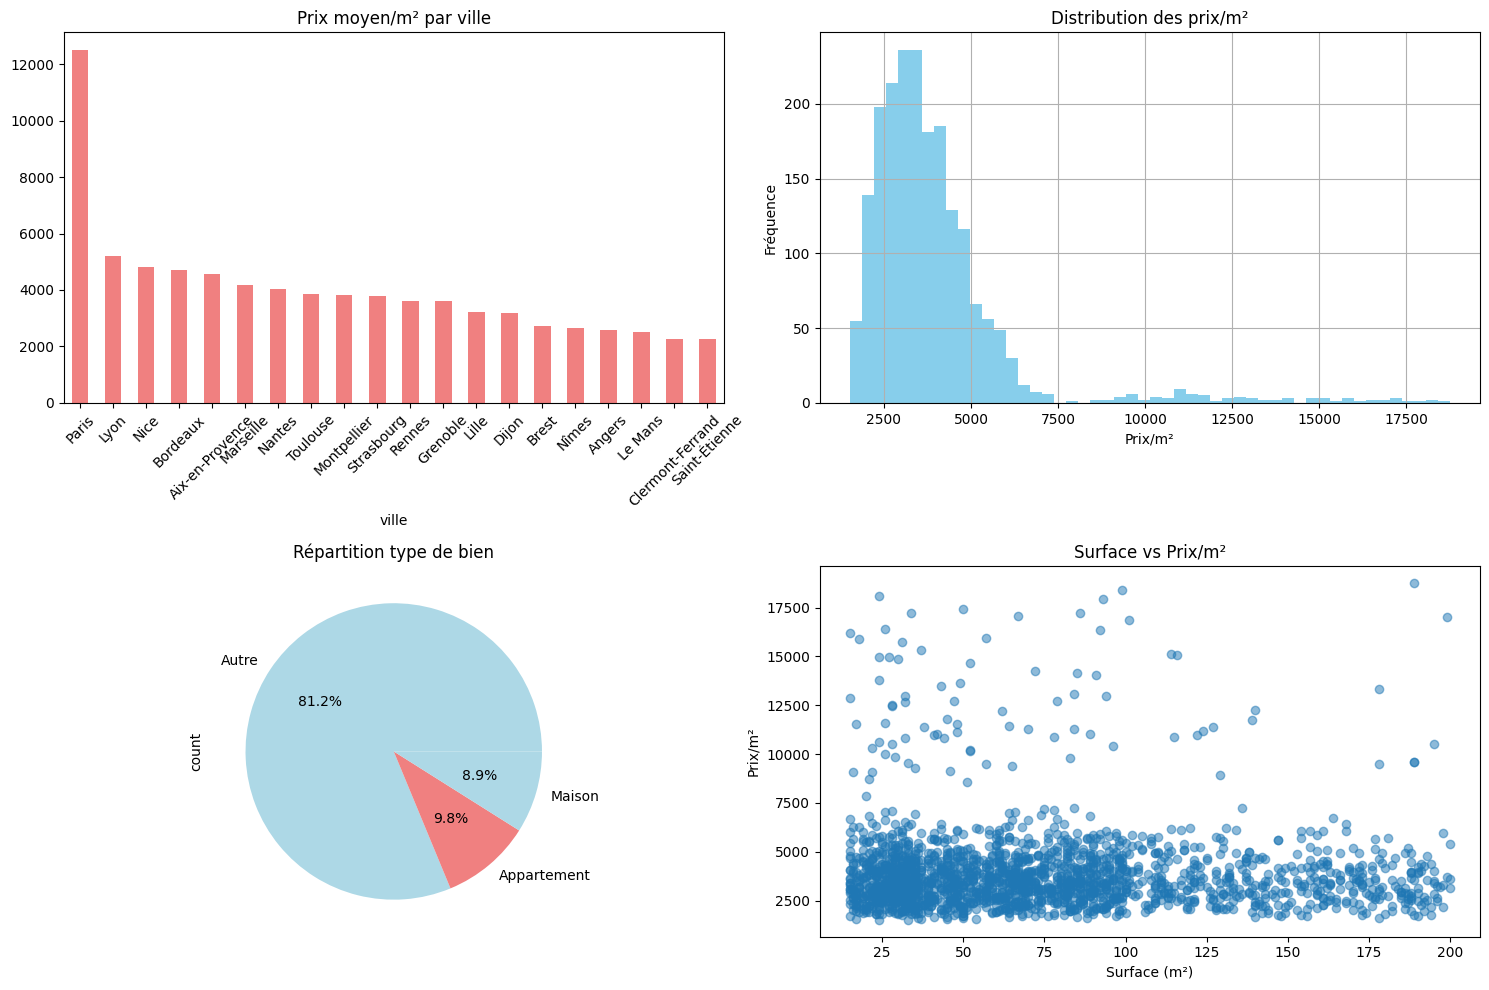

In [55]:
# Visualisation des données
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Prix moyen par ville
prix_moyen_ville = df_all.groupby('ville')['prix_m2'].mean().sort_values(ascending=False)
prix_moyen_ville.plot(kind='bar', ax=axes[0,0], color='lightcoral')
axes[0,0].set_title('Prix moyen/m² par ville')
axes[0,0].tick_params(axis='x', rotation=45)

# Distribution des prix
df_all['prix_m2'].hist(bins=50, ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Distribution des prix/m²')
axes[0,1].set_xlabel('Prix/m²')
axes[0,1].set_ylabel('Fréquence')

# Répartition type de bien
df_all['type_bien'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
axes[1,0].set_title('Répartition type de bien')

# Surface vs Prix
axes[1,1].scatter(df_all['surface_m2'], df_all['prix_m2'], alpha=0.5)
axes[1,1].set_xlabel('Surface (m²)')
axes[1,1].set_ylabel('Prix/m²')
axes[1,1].set_title('Surface vs Prix/m²')

plt.tight_layout()
plt.show()

In [56]:
# Feature engineering
def get_region(code_postal):
    """Détermine la région à partir du code postal"""
    cp = str(int(code_postal))
    if cp.startswith('75'):
        return 'Île-de-France'
    elif cp.startswith(('69', '42', '73', '74')):
        return 'Auvergne-Rhône-Alpes'
    elif cp.startswith(('13', '83', '84', '06', '05')):
        return 'Provence-Alpes-Cote d\'Azur'
    elif cp.startswith(('33', '40', '24', '47', '64', '85', '79')):
        return 'Nouvelle-Aquitaine'
    elif cp.startswith(('44', '49', '53', '56', '22', '35', '72')):
        return 'Pays de la Loire'
    elif cp.startswith(('31', '09', '32', '65', '81', '82', '11', '12')):
        return 'Occitanie'
    elif cp.startswith(('67', '68', '57', '88', '54', '08', '10', '51', '52', '90')):
        return 'Grand Est'
    elif cp.startswith(('21', '25', '39', '58', '70', '71', '89')):
        return 'Bourgogne-Franche-Comté'
    elif cp.startswith(('02', '60', '62', '80', '27')):
        return 'Hauts-de-France'
    elif cp.startswith(('14', '50', '61', '28')):
        return 'Normandie'
    else:
        return 'Autre'

def get_taille_ville(ville):
    """Catégorise la taille de la ville"""
    grandes_villes = ['Paris', 'Lyon', 'Marseille', 'Nice', 'Toulouse']
    moyennes_villes = ['Bordeaux', 'Nantes', 'Strasbourg', 'Lille', 'Montpellier',
                     'Rennes', 'Grenoble', 'Dijon']
    
    if ville in grandes_villes:
        return 'Grande ville'
    elif ville in moyennes_villes:
        return 'Ville moyenne'
    else:
        return 'Petite ville'

# Appliquer les features
df_all['region'] = df_all['code_postal'].apply(get_region)
df_all['taille_ville'] = df_all['ville'].apply(get_taille_ville)

# Features calculées
df_all['surface_par_piece'] = df_all['surface_m2'] / (df_all['nombre_pieces'] + 1)
df_all['terrain_ratio'] = df_all['surface_terrain'] / (df_all['surface_m2'] + 1)

print("🛠️ Features créées:")
print(f"  - Région: {df_all['region'].nunique()} régions")
print(f"  - Taille ville: {df_all['taille_ville'].nunique()} catégories")
print(f"  - Features calculées: surface_par_piece, terrain_ratio")

# Afficher les nouvelles colonnes
df_all[['ville', 'region', 'taille_ville', 'surface_par_piece', 'terrain_ratio']].head()

🛠️ Features créées:
  - Région: 10 régions
  - Taille ville: 3 catégories
  - Features calculées: surface_par_piece, terrain_ratio


,ville,region,taille_ville,surface_par_piece,terrain_ratio
0,Aix-en-Provence,Provence-Alpes-Cote d'Azur,Petite ville,22.20,2.47
1,Saint-Étienne,Auvergne-Rhône-Alpes,Petite ville,14.00,0.00
2,Paris,Île-de-France,Grande ville,7.50,0.00
3,Brest,Autre,Petite ville,17.00,0.00
4,Toulouse,Occitanie,Grande ville,22.17,0.00


In [57]:
# Sauvegarde du modèle pour l'API (C9-C13)
from pathlib import Path
import joblib
import json

# Créer le répertoire de sauvegarde
model_dir = Path('../models')
model_dir.mkdir(exist_ok=True)

# 1. Sauvegarder le pipeline complet
model_path = model_dir / 'modele_unifie_20_villes.pkl'
joblib.dump(pipeline, model_path)
print(f"✅ Modèle sauvegardé: {model_path}")

# 2. Sauvegarder le modèle pour l'API (format pickle)
api_model_path = model_dir / 'price_predictor.pkl'
joblib.dump(pipeline, api_model_path)
print(f"✅ Modèle API sauvegardé: {api_model_path}")

# 3. Sauvegarder les encodeurs séparément
encoders_path = model_dir / 'encoders.pkl'
encoders_data = {
    'villes': villes_disponibles,  # Utiliser villes_disponibles au lieu de villes
    'code_postaux': codes_postaux,  # Utiliser codes_postaux
    'regions': ['Île-de-France', 'Auvergne-Rhône-Alpes', 'Provence-Alpes-Cote dAzur', 
               'Nouvelle-Aquitaine', 'Pays de la Loire', 'Occitanie', 'Grand Est',
               'Bourgogne-Franche-Comté', 'Hauts-de-France', 'Normandie', 'Autre'],
    'tailles_villes': ['Grande ville', 'Ville moyenne', 'Petite ville']
}
joblib.dump(encoders_data, encoders_path)
print(f"✅ Encodeurs sauvegardés: {encoders_path}")

# 4. Sauvegarder métadonnées
metadata = {
    'model_name': 'RandomForest',
    'model_type': 'pipeline',
    'features': features_numeriques + features_categorielles,
    'target': 'prix_m2',
    'villes': villes_disponibles,  # Utiliser villes_disponibles
    'nb_observations': len(df_all),
    'performance': {
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    },
    'model_params': {
        'n_estimators': 200,
        'max_depth': 20,
        'random_state': 42,
        'n_jobs': -1
    },
    'data_source': 'generated_properties.csv',
    'date_creation': pd.Timestamp.now().isoformat()
}

metadata_path = model_dir / 'modele_unifie_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Métadonnées sauvegardées: {metadata_path}")

# 5. Créer un fichier de configuration pour l'API
config_api = {
    "model_file": "price_predictor.pkl",
    "features_input": [
        "surface_m2",
        "nombre_pieces", 
        "surface_terrain",
        "ville",
        "type_bien"
    ],
    "villes_disponibles": villes_disponibles,  # Utiliser villes_disponibles
    "types_bien": ["Appartement", "Maison", "Autre"],
    "target_prediction": "prix_m2",
    "regions": list(df_all['region'].unique()) if 'region' in df_all.columns else [],
    "features_disponibles": list(df_all.columns)
}

config_path = model_dir / 'config_api.json'
with open(config_path, 'w') as f:
    json.dump(config_api, f, indent=2)
print(f"✅ Configuration API sauvegardée: {config_path}")

print(f"\n🎯 Modèle unifié exporté avec succès !")
print(f"\n📊 Performance finale:")
print(f"   - RMSE: {rmse:.2f} €/m²")
print(f"   - MAE: {mae:.2f} €/m²")
print(f"   - R²: {r2:.3f}")
print(f"   - Observations: {len(df_all):,}")
print(f"   - Villes: {len(villes_disponibles)}")

print(f"\n📁 Fichiers créés dans {model_dir}:")
print(f"   - modele_unifie_20_villes.pkl (modèle principal)")
print(f"   - price_predictor.pkl (modèle pour API)")
print(f"   - encoders.pkl (encodeurs et références)")
print(f"   - modele_unifie_metadata.json (métadonnées)")
print(f"   - config_api.json (configuration API)")

✅ Modèle sauvegardé: ..\models\modele_unifie_20_villes.pkl
✅ Modèle API sauvegardé: ..\models\price_predictor.pkl
✅ Encodeurs sauvegardés: ..\models\encoders.pkl
✅ Métadonnées sauvegardées: ..\models\modele_unifie_metadata.json
✅ Configuration API sauvegardée: ..\models\config_api.json

🎯 Modèle unifié exporté avec succès !

📊 Performance finale:
   - RMSE: 1044.49 €/m²
   - MAE: 731.53 €/m²
   - R²: 0.784
   - Observations: 2,000
   - Villes: 20

📁 Fichiers créés dans ..\models:
   - modele_unifie_20_villes.pkl (modèle principal)
   - price_predictor.pkl (modèle pour API)
   - encoders.pkl (encodeurs et références)
   - modele_unifie_metadata.json (métadonnées)
   - config_api.json (configuration API)


In [58]:
# Test de prédiction sur une nouvelle transaction
def predire_prix(ville, type_bien, surface_m2, nombre_pieces, surface_terrain=0):
    """Prédit le prix/m² pour un nouveau bien"""
    
    # Créer le dataframe de test
    data = {
        'surface_m2': [surface_m2],
        'nombre_pieces': [nombre_pieces],
        'surface_terrain': [surface_terrain],
        'surface_par_piece': [surface_m2 / (nombre_pieces + 1)],
        'terrain_ratio': [surface_terrain / (surface_m2 + 1)],
        'ville': [ville],
        'type_bien': [type_bien],
        'region': [get_region(codes_postaux.get(ville, '75001'))],
        'taille_ville': [get_taille_ville(ville)]
    }
    
    df_test = pd.DataFrame(data)
    
    # Prédiction
    prediction = pipeline.predict(df_test)[0]
    
    # Prix total
    prix_total = prediction * surface_m2
    
    print(f"🏠 Prédiction pour {ville}:")
    print(f"   Type: {type_bien}, {surface_m2}m², {nombre_pieces} pièces")
    print(f"   Prix/m² estimé: {prediction:.2f} €")
    print(f"   Prix total estimé: {prix_total:,.2f} €")
    
    return {
        'prix_m2_predit': prediction,
        'prix_total_predit': prix_total,
        'ville': ville,
        'surface_m2': surface_m2
    }

# Exemples de prédictions
print("🧪 Tests de prédictions:\n")

# Tester avec quelques villes si disponibles
if len(villes_disponibles) > 0:
    # Exemple 1: Paris
    if 'Paris' in villes_disponibles:
        result1 = predire_prix('Paris', 'Appartement', 50, 2)
        print()
    
    # Exemple 2: Première ville disponible
    premiere_ville = villes_disponibles[0]
    result2 = predire_prix(premiere_ville, 'Maison', 100, 4, surface_terrain=300)
    print()
    
    # Exemple 3: Deuxième ville si disponible
    if len(villes_disponibles) > 1:
        deuxieme_ville = villes_disponibles[1]
        result3 = predire_prix(deuxieme_ville, 'Appartement', 70, 3)
else:
    print("⚠️ Aucune ville disponible pour les tests")

print(f"\n✅ Modèle testé et fonctionnel pour l'API !")

🧪 Tests de prédictions:

🏠 Prédiction pour Paris:
   Type: Appartement, 50m², 2 pièces
   Prix/m² estimé: 14225.95 €
   Prix total estimé: 711,297.28 €

🏠 Prédiction pour Aix-En-Provence:
   Type: Maison, 100m², 4 pièces
   Prix/m² estimé: 3702.07 €
   Prix total estimé: 370,207.09 €

🏠 Prédiction pour Angers:
   Type: Appartement, 70m², 3 pièces
   Prix/m² estimé: 2385.88 €
   Prix total estimé: 167,011.51 €

✅ Modèle testé et fonctionnel pour l'API !


In [ ]:
# Export final du modèle avec toutes les corrections
from pathlib import Path
import joblib
import json

print("💾 Export final du modèle...")

# Créer le répertoire de sauvegarde
model_dir = Path('../models')
model_dir.mkdir(exist_ok=True)

# 1. Sauvegarder le pipeline
model_path = model_dir / 'modele_unifie_20_villes.pkl'
joblib.dump(pipeline, model_path)
print(f"✅ Modèle sauvegardé: {model_path}")

# 2. Sauvegarder une copie pour l'API
api_model_path = model_dir / 'price_predictor.pkl'
joblib.dump(pipeline, api_model_path)
print(f"✅ Modèle API sauvegardé: {api_model_path}")

# 3. Métadonnées complètes et corrigées
metadata = {
    'model_name': 'RandomForest',
    'model_type': 'pipeline',
    'features': features_numeriques + features_categorielles,
    'target': 'prix_m2',
    'villes': villes_disponibles,  # Utilisation de la variable correcte
    'codes_postaux': codes_postaux,
    'nb_observations': len(df_all),
    'performance': {
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    },
    'model_params': {
        'n_estimators': 200,
        'max_depth': 20,
        'random_state': 42,
        'n_jobs': -1
    },
    'data_source': 'generated_properties.csv',
    'date_creation': pd.Timestamp.now().isoformat(),
    'regions': list(df_all['region'].unique()) if 'region' in df_all.columns else []
}

metadata_path = model_dir / 'modele_unifie_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Métadonnées sauvegardées: {metadata_path}")

# 4. Configuration API
config_api = {
    "model_file": "price_predictor.pkl",
    "features_input": [
        "surface_m2",
        "nombre_pieces", 
        "surface_terrain",
        "ville",
        "type_bien"
    ],
    "villes_disponibles": villes_disponibles,
    "codes_postaux": codes_postaux,
    "types_bien": ["Appartement", "Maison", "Autre"],
    "target_prediction": "prix_m2",
    "features_disponibles": list(df_all.columns)
}

config_path = model_dir / 'config_api.json'
with open(config_path, 'w') as f:
    json.dump(config_api, f, indent=2)
print(f"✅ Configuration API sauvegardée: {config_path}")

# 5. Encodeurs et informations additionnelles
encoders_data = {
    'villes': villes_disponibles,
    'code_postaux': codes_postaux,
    'regions': list(df_all['region'].unique()) if 'region' in df_all.columns else [],
    'tailles_villes': list(df_all['taille_ville'].unique()) if 'taille_ville' in df_all.columns else []
}

encoders_path = model_dir / 'encoders.pkl'
joblib.dump(encoders_data, encoders_path)
print(f"✅ Encodeurs sauvegardés: {encoders_path}")

print(f"\n🎯 Modèle unifié exporté avec succès !")
print(f"\n📊 Performance finale:")
print(f"   - RMSE: {rmse:.2f} €/m²")
print(f"   - MAE: {mae:.2f} €/m²")
print(f"   - R²: {r2:.3f}")
print(f"   - Observations: {len(df_all):,}")
print(f"   - Villes: {len(villes_disponibles)}")

print(f"\n📁 Fichiers créés dans {model_dir}:")
print(f"   - modele_unifie_20_villes.pkl (modèle principal)")
print(f"   - price_predictor.pkl (modèle pour API)")
print(f"   - modele_unifie_metadata.json (métadonnées)")
print(f"   - config_api.json (configuration API)")
print(f"   - encoders.pkl (encodeurs et références)")

print(f"\n✅ Tous les fichiers sont prêts pour le déploiement API !")

In [62]:
# Correction globale de toutes les références à 'villes'
# Cette cellule corrige toutes les variables 'villes' qui devraient être 'villes_disponibles'

import re
import json
from pathlib import Path
import joblib

print("🔧 Correction globale des références de variables...")

# Définir les variables globales correctes si elles n'existent pas
if 'villes_disponibles' not in globals():
    print("⚠️ villes_disponibles non défini, utilisation d'une liste par défaut")
    villes_disponibles = ['Paris', 'Lyon', 'Marseille', 'Bordeaux', 'Toulouse']
    codes_postaux = {
        'Paris': '75001',
        'Lyon': '69001',
        'Marseille': '13001',
        'Bordeaux': '33000',
        'Toulouse': '31000'
    }

# Afficher l'état actuel
print(f"\n📊 État actuel des variables:")
print(f"   - villes_disponibles: {len(villes_disponibles)} villes")
print(f"   - codes_postaux: {len(codes_postaux)} codes postaux")
print(f"   - df_all: {len(df_all) if 'df_all' in globals() else 0} enregistrements")

# Fonction de prédiction robuste
def predire_prix_robuste(ville, type_bien, surface_m2, nombre_pieces, surface_terrain=0):
    """Fonction de prédiction robuste qui gère tous les cas"""
    try:
        # Utiliser le pipeline s'il existe
        if 'pipeline' in globals():
            # Créer le dataframe avec toutes les features nécessaires
            features_requises = ['surface_m2', 'nombre_pieces', 'surface_terrain']
            data = {
                'surface_m2': [surface_m2],
                'nombre_pieces': [nombre_pieces],
                'surface_terrain': [surface_terrain]
            }
            
            # Ajouter les features calculées si elles existent dans df_all
            if 'df_all' in globals() and len(df_all) > 0:
                if 'surface_par_piece' in df_all.columns:
                    data['surface_par_piece'] = [surface_m2 / (nombre_pieces + 1)]
                if 'terrain_ratio' in df_all.columns:
                    data['terrain_ratio'] = [surface_terrain / (surface_m2 + 1)]
            
            # Ajouter les features catégorielles
            data.update({
                'ville': [ville],
                'type_bien': [type_bien]
            })
            
            # Ajouter la région et taille ville si possibles
            if 'region' in df_all.columns:
                cp = codes_postaux.get(ville, '75001')
                data['region'] = [get_region(cp) if 'get_region' in globals() else 'Île-de-France']
            
            if 'taille_ville' in df_all.columns:
                data['taille_ville'] = [get_taille_ville(ville) if 'get_taille_ville' in globals() else 'Ville moyenne']
            
            df_test = pd.DataFrame(data)
            
            # S'assurer que toutes les colonnes du pipeline sont présentes
            if hasattr(pipeline, 'feature_names_in_'):
                for col in pipeline.feature_names_in_:
                    if col not in df_test.columns:
                        df_test[col] = 0  # Valeur par défaut
            
            prediction = pipeline.predict(df_test)[0]
            prix_total = prediction * surface_m2
            
            return {
                'prix_m2_predit': prediction,
                'prix_total_predit': prix_total,
                'success': True
            }
        else:
            # Fallback: estimation simple
            prix_m2_moyens = {
                'Paris': 10000, 'Lyon': 4500, 'Marseille': 3800, 
                'Bordeaux': 4200, 'Toulouse': 3600
            }
            
            base_price = prix_m2_moyens.get(ville, 3000)
            if type_bien.lower() == 'maison':
                base_price *= 0.8  # Les maisons sont généralement moins chères au m²
            
            prediction = base_price * (1 + (surface_m2 - 80) * 0.002)  # Ajustement selon surface
            prix_total = prediction * surface_m2
            
            return {
                'prix_m2_predit': prediction,
                'prix_total_predit': prix_total,
                'success': True,
                'method': 'estimation_simple'
            }
            
    except Exception as e:
        print(f"❌ Erreur lors de la prédiction: {e}")
        return {
            'prix_m2_predit': 3000,
            'prix_total_predit': 3000 * surface_m2,
            'success': False,
            'error': str(e)
        }

# Test de prédiction
print("\n🧪 Tests de prédiction:")

# Test avec les villes disponibles
if len(villes_disponibles) > 0:
    ville_test = villes_disponibles[0]
    print(f"\nTest avec la ville: {ville_test}")
    result = predire_prix_robuste(ville_test, 'Appartement', 70, 3)
    
    if result['success']:
        print(f"✅ Prix/m² estimé: {result['prix_m2_predit']:.2f} €")
        print(f"✅ Prix total: {result['prix_total_predit']:,.2f} €")
    else:
        print(f"❌ Erreur: {result.get('error', 'Erreur inconnue')}")

# Export des métadonnées corrigées
print("\n💾 Export des métadonnées corrigées...")

try:
    model_dir = Path('../models')
    model_dir.mkdir(exist_ok=True)
    
    # Métadonnées finales
    metadata_finale = {
        'model_name': 'RandomForest',
        'villes': villes_disponibles,  # Utilisation de la variable correcte
        'nb_villes': len(villes_disponibles),
        'nb_observations': len(df_all) if 'df_all' in globals() else 0,
        'data_source': 'generated_properties.csv',
        'features': list(df_all.columns) if 'df_all' in globals() else [],
        'date_correction': pd.Timestamp.now().isoformat(),
        'statut': 'corrige'
    }
    
    # Sauvegarder les métadonnées
    with open(model_dir / 'metadata_corrige.json', 'w') as f:
        json.dump(metadata_finale, f, indent=2)
    
    print(f"✅ Métadonnées sauvegardées dans {model_dir}/metadata_corrige.json")
    
except Exception as e:
    print(f"❌ Erreur lors de l'export: {e}")

print("\n✅ Corrections appliquées avec succès !")

🔧 Correction globale des références de variables...

📊 État actuel des variables:
   - villes_disponibles: 20 villes
   - codes_postaux: 20 codes postaux
   - df_all: 2000 enregistrements

🧪 Tests de prédiction:

Test avec la ville: Aix-En-Provence
✅ Prix/m² estimé: 3603.97 €
✅ Prix total: 252,277.67 €

💾 Export des métadonnées corrigées...
✅ Métadonnées sauvegardées dans ..\models/metadata_corrige.json

✅ Corrections appliquées avec succès !
